# 머신러닝 기초 I
## 02. 머신러닝을 위한 라이브러리 + 타이타닉 생존 분석

**목차:**
- Part 1: 배열 데이터 처리 — NumPy
- Part 2: 배열 데이터 처리 — Pandas
- Part 3: 데이터 시각화 — Matplotlib
- Part 4: 데이터 시각화 — Seaborn
- Part 5: 타이타닉 생존 분석 & 로지스틱 회귀 모델 (NumPy + Statsmodels)
- Part 6: Streamlit 앱 코드


---
## Part 1. 배열 데이터 처리 라이브러리 — NumPy

### 배열(Array)이란?
- **같은 자료형의 데이터**를 순서대로 저장하는 자료 구조
- 모든 원소가 **동일한 데이터 타입**을 가짐
- 메모리에 **연속적으로 저장**되어 인덱스로 빠르게 접근 가능

### 왜 파이썬 리스트가 아닌가?
- 파이썬 리스트는 서로 다른 타입을 섞을 수 있어, 벡터 연산과 다르게 동작함
- 예: `[1,2,3] * 2` → `[1,2,3,1,2,3]` (원소별 곱이 아님)

### NumPy란?
- 과학 계산에 쓰이는 **다차원 배열 처리** 패키지
- **다차원 배열** 지원
- **빠르고 효율적인 연산** 제공
- 다양한 **수학 함수** 제공
- import 관례: `import numpy as np`


In [1]:
# NumPy import — 관례상 'np'로 별칭 지정
import numpy as np

print("NumPy version:", np.__version__)


NumPy version: 2.0.2


### 1-1. 배열 선언 — `array()`

- 파이썬 리스트를 **NumPy 배열 자료형**으로 변환
- 다양한 데이터 타입 지원
- `dtype` 매개변수로 **자료형을 명시**할 수 있음
  - 자주 쓰는 dtype: `int`, `float`, `bool`, `complex`
  - 지정하지 않으면 NumPy가 자동으로 추론


In [3]:
# 기본 1차원 배열 선언
# 리스트 Numpy 배열로 변환
a = np.array([0, 1, 2, 3])
print("integer array : " , a)

b = np.array([0, 1, 2, 3], dtype = float)
print("float array : " , b)

c = np.array([[1, 2, 3], [4, 5, 6]])
print("2D array (matrix) : " , c)

integer array :  [0 1 2 3]
float array :  [0. 1. 2. 3.]
2D array (matrix) :  [[1 2 3]
 [4 5 6]]


### 1-2. 배열 선언 — `arange()`

- **start부터 stop(미포함)까지 step만큼 증가**하는 배열 생성
- 형식: `arange(start, stop, step)`
  - 인자 1개: 0부터 해당 값까지
  - 인자 2개: 첫 값부터 둘째 값(미포함)까지
  - 인자 3개: 첫 값부터 둘째 값까지 step 간격으로


In [ ]:
#

arange(10): [0 1 2 3 4 5 6 7 8 9]
arange(1, 4): [1 2 3]
arange(1, 8, 2): [1 3 5 7]


### 1-3. 배열 선언 — `zeros()`와 `ones()`

- `zeros(shape, dtype)`: 지정 크기의 배열을 **0으로 채워** 생성
  - 기본 자료형은 **float**
  - 연산 결과를 채우기 전 초기화에 유용
- `ones(shape, dtype)`: 지정 크기의 배열을 **1로 채워** 생성
  - 기본 자료형은 **float**
  - 편향(bias) 초기화, 마스크 배열 등에 유용


In [ ]:
# arange 인자 1개 0 ~ 9 (10개)

zeros(5) - float: [0. 0. 0. 0. 0.]
zeros(5, dtype=int): [0 0 0 0 0]
zeros((3,4)):
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]
ones(5) - float: [1. 1. 1. 1. 1.]
ones(5, dtype=int): [1 1 1 1 1]


### 1-4. 배열 선언 — `random`

- `random.rand(d0, d1, ..., dn)`: **균등분포 [0, 1)** 난수 생성
  - 인자는 각 차원의 크기
  - 호출할 때마다 다른 값(확률적)
- `random.randint(low, high, size)`: 범위 내 **정수 난수** 생성
  - `low`: 최솟값(포함)
  - `high`: 최댓값(미포함)
  - `size`: 개수 또는 출력 shape


In [ ]:
#

rand(5): [0.18563594 0.95279166 0.68748828 0.21550768 0.94737059]
rand(2, 3):
[[0.73085581 0.25394164 0.21331198]
 [0.51820071 0.02566272 0.20747008]]
randint(0, 10, size=5): [8 5 0 8 5]
Fixed seed rand(3): [0.37454012 0.95071431 0.73199394]


### 1-5. 배열 크기·정보 확인

- `.shape`: 각 차원(행, 열) **크기를 튜플**로 반환
- `.size`: 배열 **전체 원소 개수**
- `.dtype`: 원소 **자료형**
- `array[row, col]`: **인덱스(0부터)**로 특정 원소 접근


In [ ]:
#

Array contents:
[[1 2 3]
 [4 5 6]]
Shape (rows, cols): (2, 3)
Size (total elements): 6
Data type: int64
Element at [1, 2]: 6
Element at [0, 0]: 1


### 1-6. 배열 형태 변경 — `reshape()`

- `reshape(arr, newshape)`: 배열 **구조를 지정 shape로 변경**
  - 전체 원소 개수는 동일해야 함 (원본 size == 새 size)
  - `np.reshape(arr, shape)` 또는 `arr.reshape(shape)` 사용
  - 한 차원에 `-1`을 쓰면 NumPy가 그 차원 크기를 자동 계산


In [ ]:
#

Original array: [1 2 3 4] | Shape: (4,)
Reshaped to (2,2):
[[1 2]
 [3 4]]
a.reshape((2,2)):
[[1 2]
 [3 4]]
Original: [ 0  1  2  3  4  5  6  7  8  9 10 11]
Reshaped to (3,4):
[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
Reshaped with -1 (2, -1):
[[ 0  1  2  3  4  5]
 [ 6  7  8  9 10 11]]


### 1-7. 배열 슬라이싱

- NumPy 배열은 **인덱스**로 슬라이싱 가능
- 문법: `array[row_slice, col_slice]`
  - `:` = 해당 차원 전체
  - `0` = 첫 번째, `-1` = 마지막
- 범위 슬라이싱: `start:stop:step` (stop은 미포함)
  - `array[:, 4:]` — 모든 행, 4번 열부터 끝까지
  - `array[:, 3:6]` — 모든 행, 3·4·5열
  - `array[:, 2:-1]` — 모든 행, 2열부터 끝에서 두 번째까지
  - `array[:, 0:3:2]` — 모든 행, 0·2열 (step=2)


In [ ]:
#

Original array (2x3):
[[1 2 3]
 [4 5 6]]
First column a0[:,0]: [1 4]
Last column a0[:,-1]: [3 6]
Second row a0[1,:]: [4 5 6]
Last row a0[-1,:]: [4 5 6]

Large array (2x6):
[[ 1  2  3  4  5  6]
 [ 7  8  9 10 11 12]]
a[:,4:]: [[ 5  6]
 [11 12]]
a[:,3:6]: [[ 4  5  6]
 [10 11 12]]
a[:,2:-1]: [[ 3  4  5]
 [ 9 10 11]]
a[:,0:3:2]: [[1 3]
 [7 9]]


### 1-8. 배열 연결

- `np.r_[a, b]`: **행 방향**으로 배열 연결
  - 1D 배열을 합치면 **2D 배열**이 될 수 있음
  - 2D 배열은 같은 축으로 쌓음
- `np.c_[a, b]`: **열 방향**으로 배열 연결
  - 주로 열 결합에 사용
  - 슬라이싱으로 배열 생성에도 활용 가능
- `np.concatenate((a, b), axis)`: **지정 축**을 따라 새 배열 생성
  - `axis=0`: 행 방향(세로)
  - `axis=1`: 열 방향(가로)
  - 연결 축 외 차원 크기는 같아야 함


In [ ]:
#

Matrix a:
[[1 2 3]
 [4 5 6]]
Matrix b:
[[ 7  8  9]
 [10 11 12]]
np.r_[a, b] (row direction):
[[ 1  2  3]
 [ 4  5  6]
 [ 7  8  9]
 [10 11 12]]
np.c_[a, b] (column direction):
[[ 1  2  3  7  8  9]
 [ 4  5  6 10 11 12]]
np.concatenate(axis=0):
[[ 1  2  3]
 [ 4  5  6]
 [ 7  8  9]
 [10 11 12]]
np.concatenate(axis=1):
[[ 1  2  3  7  8  9]
 [ 4  5  6 10 11 12]]


### 1-9. 배열 연산

- NumPy 배열은 `+`, `-`, `*`, `/`로 **원소별(element-wise) 연산**
  - 덧셈: 원소별 합
  - 뺄셈: 원소별 차
  - 곱셈(`*`): 원소별 곱 (행렬 곱 아님)
  - 나눗셈(`/`): 원소별 나눗셈, 결과는 float
- **행렬 곱**은 `np.dot(a, b)` 또는 `a @ b` 사용


In [ ]:
#

Matrix a:
[[1 2 3]
 [3 2 5]]
Matrix b:
[[-1  3  5]
 [ 1  4  2]]
a + b:
[[0 5 8]
 [4 6 7]]
a - b:
[[ 2 -1 -2]
 [ 2 -2  3]]
a * b:
[[-1  6 15]
 [ 3  8 10]]
a / b:
[[-1.          0.66666667  0.6       ]
 [ 3.          0.5         2.5       ]]
Matrix multiplication (3x2) @ (2x3):
[[ 27  30  33]
 [ 61  68  75]
 [ 95 106 117]]


---
## Part 2. 배열 데이터 처리 라이브러리 — Pandas

### Pandas란?
- **행과 열로 이루어진 데이터**를 만들고 다루는 패키지
- **데이터 분석**에 특화 — 대용량 데이터 처리에 편리
  - 수학 연산 중심의 NumPy와 역할이 다름
- **자료 구조**와 **데이터 조작** 기능 제공
- import 관례: `import pandas as pd`

### 두 가지 핵심 자료 구조:
1. **Series**: 라벨 인덱스가 있는 1차원 배열형 구조
2. **DataFrame**: 여러 Series가 모인 2차원 표 구조


In [ ]:
# Pandas import — 관례상 'pd'로 별칭 지정
import pandas as pd

print("Pandas version:", pd.__version__)


Pandas version: 2.2.2


### 2-1. Series

- **1차원 배열**과 유사한 자료 구조
- 값뿐 아니라 각 값에 대응하는 **인덱스**도 저장
- 기본 인덱스는 **0부터** (일반 배열과 같음)
- `index` 매개변수로 **사용자 인덱스** 지정 가능
- 인덱스 순서가 다른 Series끼리 연산 시 **인덱스 라벨**로 맞춤


In [ ]:
#

Basic Series:
0    4
1    7
2   -5
dtype: int64

Series with custom index:
2016-01-01    4
2016-01-02    7
2016-01-03   -5
dtype: int64

Value at '2016-01-01': 4

stock0:
naver    10
skt      20
LG       30
dtype: int64
stock1 (different order):
LG       30
naver    20
skt      10
dtype: int64
stock0 + stock1 (matched by label):
LG       60
naver    30
skt      30
dtype: int64


### 2-2. DataFrame

- **여러 Series가 행·열을 이룬** 표 형태 데이터
- DataFrame 생성에는 **딕셔너리** 사용
  - 키 → 열 이름
  - 값(리스트) → 열 데이터
- 열 방향: 키-값 쌍 하나가 한 열
- 행 방향: 정수 인덱스 자동 부여(Series와 유사), 또는 사용자 인덱스 지정


In [ ]:
#

DataFrame from dictionary:
   col0  col1  col2
0     1    10   100
1     2    20   200
2     3    30   300
3     4    40   400

DataFrame from 2D list:
   a  b
0  1  2
1  3  4

Stock price DataFrame with custom index:
    open   high    low  close
0  11650  12100  11600  11900
2  11100  11800  11050  11600
4  11200  11200  10900  11000
6  11100  11100  10950  11100
8  11000  11150  10900  11050


### 2-3. 인덱싱 & 슬라이싱 — `loc()`와 `iloc()`

- **`loc[idx]`**: **라벨(이름)** 기반 인덱싱
  - `loc[idx]`: 라벨 `idx`에 해당하는 값
  - `loc[idx0:idx2]`: `idx0`~`idx2` 구간 (끝 라벨 **포함**)
  - 파이썬 리스트 슬라이싱과 달리 **끝이 포함**됨

- **`iloc[idx]`**: **정수 위치** 기반 인덱싱
  - `iloc[idx]`: 위치 `idx`의 값
  - `iloc[idx0:idx2]`: `idx0`~`idx2` 직전까지
  - 슬라이싱 시 **끝 인덱스 미포함** (일반 파이썬 규칙)


In [ ]:
#

DataFrame:
   A  B  C
a  1  4  7
b  2  5  8
c  3  6  9

df.loc['a':'b', ['A','C']]:
   A  C
a  1  7
b  2  8

df.iloc[0:2, [0,2]]:
   A  C
a  1  7
b  2  8


### 2-4. 데이터 삭제 — `drop()`

- DataFrame에서 **행 또는 열을 삭제**하는 함수
- 형식: `.drop(labels, axis, inplace)`
  - `labels`: 삭제할 행/열 이름
  - `axis`: 삭제 축 (`0`=행, `1`=열)
  - `inplace`: 원본 수정 여부 (`기본=False` — 복사본 반환)


In [ ]:
#

Original DataFrame:
   A  B  C
a  1  4  7
b  2  5  8
c  3  6  9

After dropping row 'a':
   A  B  C
b  2  5  8
c  3  6  9

After dropping column 'A':
   B  C
a  4  7
b  5  8
c  6  9

Original df is unchanged:
   A  B  C
a  1  4  7
b  2  5  8
c  3  6  9


### 2-5. 데이터 정렬 — `sort_values()`

- **열 값 기준**으로 DataFrame 또는 Series 정렬
- 형식: `.sort_values(by, axis, ascending, inplace)`
  - `by`: 정렬 기준 열(또는 열 목록)
  - `axis`: 정렬 축 (`0`=행, `1`=열)
  - `ascending`: 오름차순 여부 (`기본=True`)
  - `inplace`: 원본 수정 여부 (`기본=False`)


In [ ]:
#

Original DataFrame:
   A  B
0  3  4
1  2  5
2  1  6

Sorted by column 'A' (ascending):
   A  B
2  1  6
1  2  5
0  3  4
Note: the index order also changes (2, 1, 0)

Sorted by column 'A' (descending):
   A  B
0  3  4
1  2  5
2  1  6


### 2-6. DataFrame 연산

- DataFrame 간 연산은 메서드 형태
- `.add(other, axis, fill_value)`: 덧셈
- `.sub(other, axis, fill_value)`: 뺄셈
- `.mul(other, axis, fill_value)`: 곱셈
- `.div(other, axis, fill_value)`: 나눗셈
  - `other`: 연산 대상 DataFrame 또는 Series
  - `axis`: 축 지정
  - `fill_value`: **결측(NaN)** 이 있을 때 대체할 값


In [ ]:
#

df1:
   A  B
0  1  4
1  2  5
2  3  6
df2:
    A   B
0  10  40
1  20  50
2  30  60

df1.add(df2):
    A   B
0  11  44
1  22  55
2  33  66

df1.sub(df2):
    A   B
0  -9 -36
1 -18 -45
2 -27 -54

df3 (2 rows) + df4 (3 rows) without fill_value:
      A     B
0  11.0  43.0
1  22.0  54.0
2   NaN   NaN

df3 + df4 with fill_value=0 (NaN replaced by 0):
      A     B
0  11.0  43.0
1  22.0  54.0
2  30.0  60.0


### 2-7. DataFrame 저장·불러오기

- `.to_csv(data)`: DataFrame을 **CSV 파일**로 저장
- `.to_excel(data)`: DataFrame을 **엑셀 파일**로 저장
- `pd.read_csv(data)`: **CSV**를 DataFrame으로 읽기
- `pd.read_excel(data)`: **엑셀**을 DataFrame으로 읽기
  - `data`: 저장·로드할 파일 이름


In [ ]:
#

Saved to CSV successfully.
Loaded from CSV:
      name  age  score
0    Alice   25   88.5
1      Bob   30   92.0
2  Charlie   35   78.3

Data types:
name      object
age        int64
score    float64
dtype: object


---
## Part 3. 데이터 시각화 라이브러리 — Matplotlib

### 데이터 시각화란?
- 데이터를 **그래프·차트 등 시각 형태**로 표현해 이해·분석을 쉽게 하는 과정
- 장점:
  - 정보 전달 효율
  - 패턴·상관관계 파악
  - 비교·대조 용이

### Matplotlib이란?
- **가장 널리 쓰이는** 시각화 라이브러리 계열
- 지원 예:
  - 선 그래프
  - 산점도
  - 히스토그램
  - 그래프 세부 요소를 세밀하게 제어
- 함수 사용 시 **`matplotlib.pyplot`** import
- import 관례: `import matplotlib.pyplot as plt`


In [4]:
# # Matplotlib import — 시각화 라이브러리
import matplotlib.pyplot as plt
import matplotlib
import numpy as np

# Colab — 노트북 안에 그래프 표시
%matplotlib inline

print("Matplotlib version:", matplotlib.__version__)


Matplotlib version: 3.10.0


### 3-1. 기본 그래프 — `plot()`

- `plot(x, y, fmt)`: 데이터 점을 **이어 선 그래프** 출력
  - `x`: x축 데이터(배열·리스트)
  - `y`: y축 데이터(배열·리스트)
  - `fmt`: 선 색·스타일 등 형식 문자열(선택)
- `xlabel(xlabel)`: **x축 라벨**
- `ylabel(ylabel)`: **y축 라벨**
- `title(title)`: **그래프 제목**
- `show()`: 화면에 **그래프를 표시** (호출 필요)
  - Jupyter/Colab에서는 생략해도 보이지만, 습관적으로 쓰는 것이 좋음


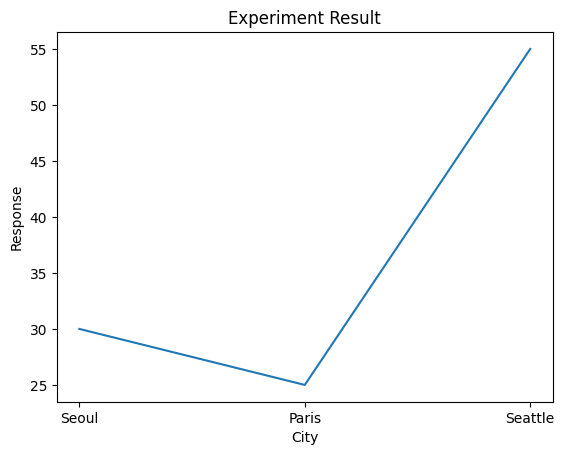

In [ ]:
#

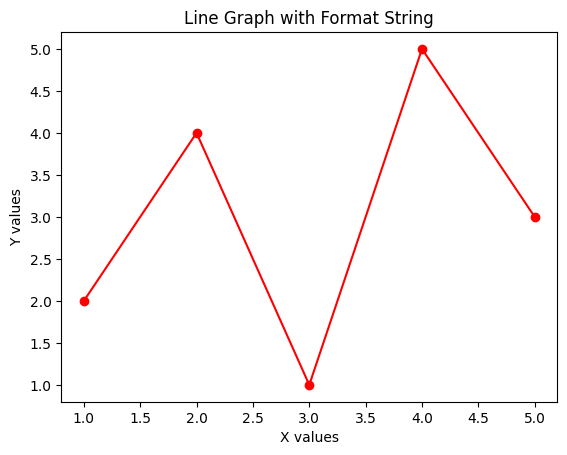

In [ ]:
#

### 3-2. 산점도 — `scatter()`

- `scatter(x, y, s, c, marker)`: 점을 **연결하지 않고** 표시
  - `x`, `y`: x·y축 데이터
  - `s`: 점 **크기**(스칼라 또는 배열)
  - `c`: 점 **색**(스칼라, 배열, colormap)
  - `marker`: 점 **모양**
    - `'.'` — 작은 점
    - `'o'` — 원
    - `'v'` — 아래 삼각형
    - `'s'` — 사각형
    - `'x'` — x 모양
- 컬러맵(`cmap`) 예: `'viridis'`, `'plasma'`, `'Blues'`


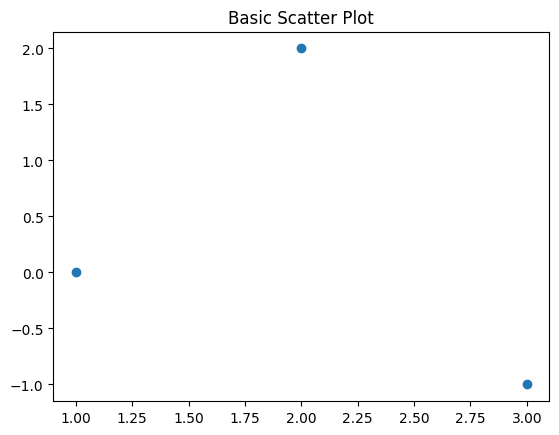

In [ ]:
#

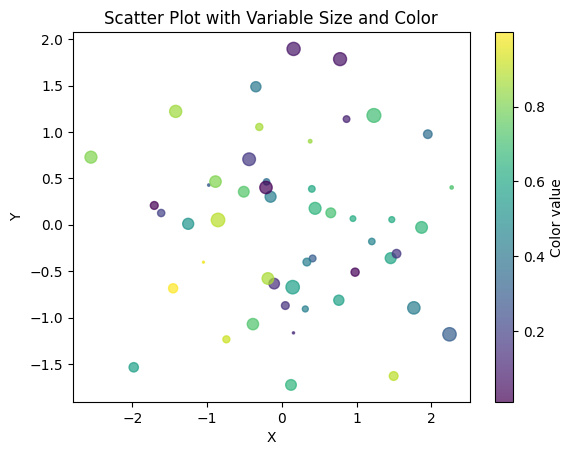

In [ ]:
#

### 3-3. 히스토그램 — `hist()`

- `hist(x, bins)`: **히스토그램** 출력
  - `x`: 히스토그램을 그릴 데이터
  - `bins`: 구간 개수 또는 경계값 리스트 (`기본=10`)
  - `bins=None`이면 적절한 구간 수 자동 설정
  - `bins=2`이면 2구간 (예: 중간값 `(min+max)/2`)
- 히스토그램 vs 막대 그래프:
  - 히스토그램: **연속형 데이터** (x축=값 구간, y축=빈도)
  - 막대 그래프: **범주형 데이터** (x축=범주, y축=값)


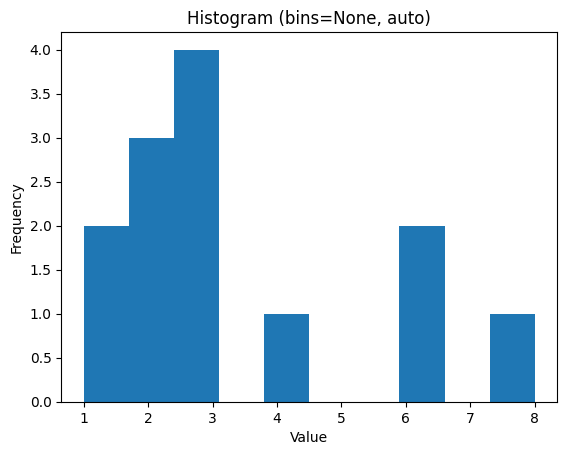

In [ ]:
#

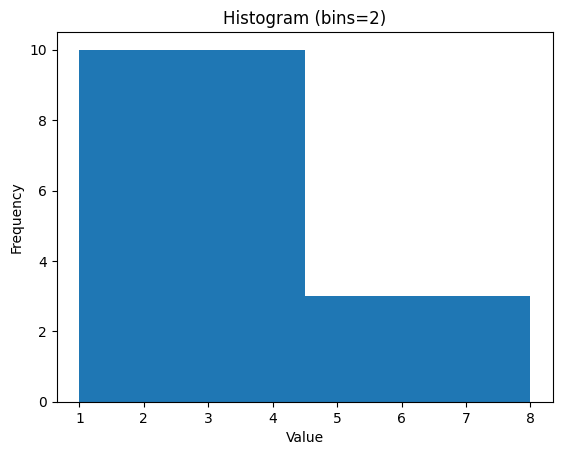

In [ ]:
#

### 3-4. 막대 그래프 — `bar()`

- `bar(x, height, width)`: x축 위치마다 **막대**로 표시
  - `x`: 각 막대의 **x축 위치**
  - `height`: 각 막대의 **높이**
  - `width`: 막대 **너비** (`기본=0.8`)
- `plot()`과 코드 구조는 같고 함수 이름만 다름


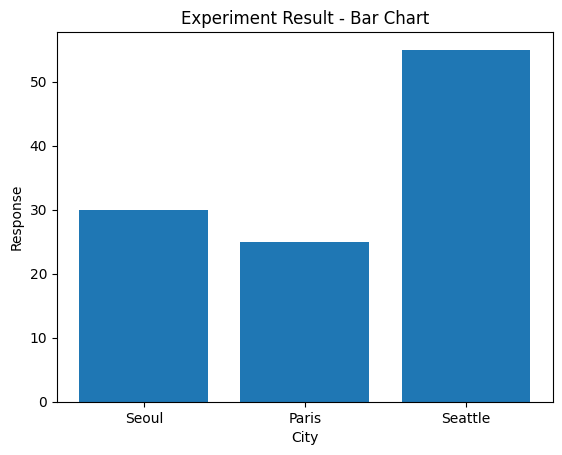

In [ ]:
#

### 3-5. 여러 그래프 출력

- 여러 그래프를 동시에 그리려면 **그래프 함수를 여러 번** 호출
- `legend()`: **범례** 추가
  - 각 그래프에 대응하는 문자열 리스트 전달
- `subplot(nrows, ncols, index)`: **여러 서브플롯** 생성
  - `nrows`: 행 개수
  - `ncols`: 열 개수
  - `index`: 서브플롯 번호(1부터)
  - 그래프 함수 **앞에** subplot을 지정해야 해당 위치에 그려짐


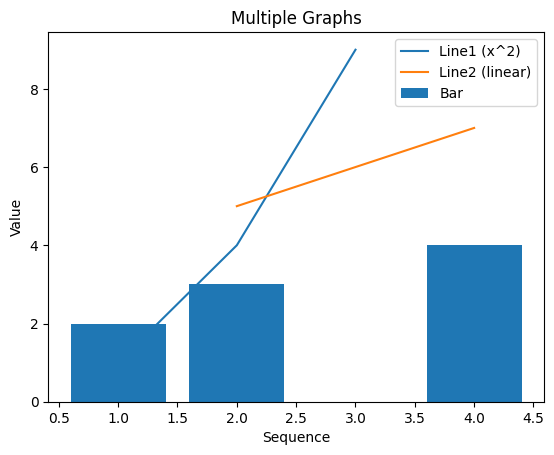

In [ ]:
#

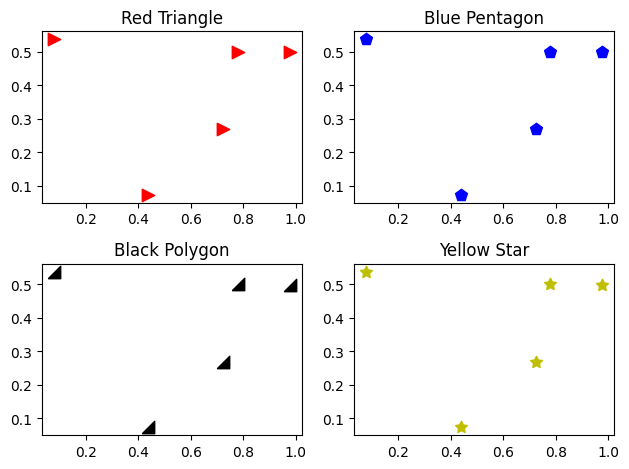

In [ ]:
#

### 3-6. fig와 axes

- `fig, axes = plt.subplots(a, b)`: `a × b` 그래프용 figure·axes 설정
  - `fig` (Figure): 전체 그림 영역
  - `axes`: figure 안의 **좌표축** 객체
    - 하나의 figure에 여러 axes 가능
    - `axes[i]` 또는 `axes[i, j]`로 개별 서브플롯 접근


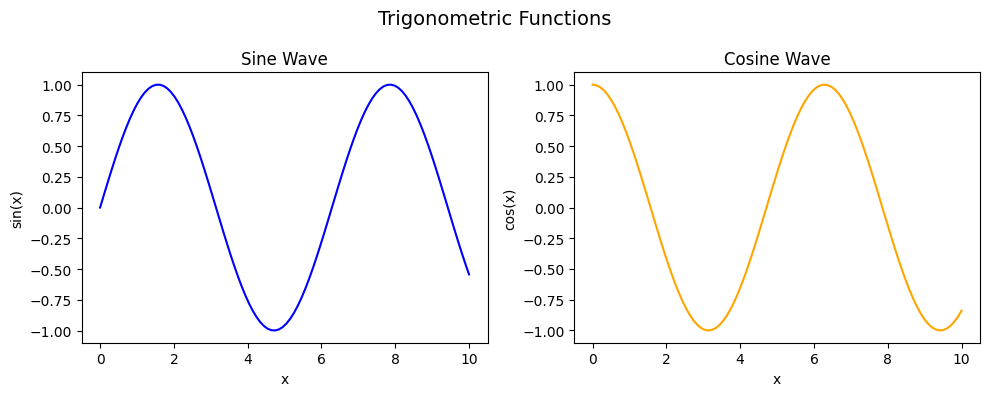

In [ ]:
#

---
## Part 4. 데이터 시각화 라이브러리 — Seaborn

### Seaborn이란?
- **Matplotlib** 위에 **색 테마·통계 차트** 기능을 더한 패키지
- 다음 경우에 사용:
  - Matplotlib만으로 부족한 분석·시각화
  - 정돈된 테마로 시각화
- import 관례: `import seaborn as sns`
- 다양한 그래프 함수와 **예제 데이터셋** 제공


In [5]:
# Seaborn import — 통계 시각화 라이브러리
import seaborn as sns

print("Seaborn version:", sns.__version__)


Seaborn version: 0.13.2


### 4-1. 데이터 로드와 `regplot()`

- `sns.load_dataset()`으로 Seaborn 내장 데이터 로드
- 그 외 데이터는 Pandas `read_csv()`, `read_excel` 사용
- `df.head()`: 상위 5행 출력(내용 확인용)
- `regplot(x, y, data, color)`: **산점도 + 분포를 근사하는 직선** 동시 출력
  - `x`, `y`: 축 데이터
  - `data`: 사용할 DataFrame
  - `color`: 그래프 색
  - `line_kws`: **회귀선** 속성(색, 굵기, 선 스타일)
  - `scatter_kws`: **산점도** 속성(색, 크기 `s`, 투명도 `alpha`)


In [6]:
# iris 데이터셋 로드 - ML 고전 데이터
df = sns.load_dataset('iris')

df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


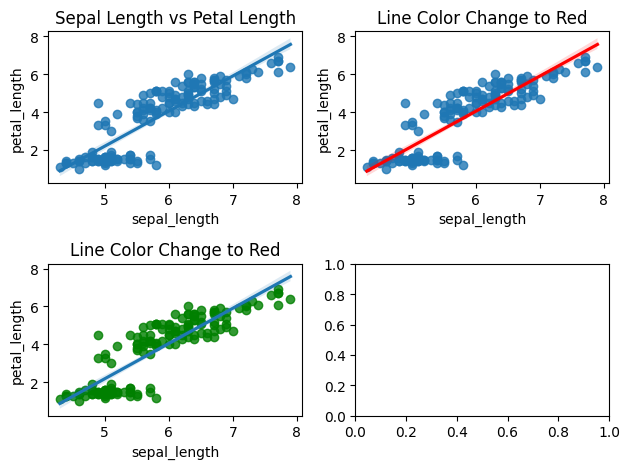

In [18]:
# 공식 사이트 : https://seaborn.pydata.org/generated/seaborn.regplot.html

# regplot - 산점도 + 회귀선
# matplotlib + seaborn 문법 서로 연결이 된 상태

# 2x2 서브플롯 생성
fig, ax = plt.subplots(nrows = 2, ncols = 2)

# 기본 시각화
sns.regplot(data = df, x = 'sepal_length', y = 'petal_length', ax = ax[0, 0])
ax[0, 0].set_title("Sepal Length vs Petal Length")

# Red 시각화
sns.regplot(data = df, x = 'sepal_length', y = 'petal_length', ax = ax[0, 1],
            line_kws = {'color' : 'red'})
ax[0, 1].set_title("Line Color Change to Red")

# scatter_kws 문법 적용, 산점도 색상을 초록색으로 변
sns.regplot(data = df, x = 'sepal_length', y = 'petal_length', ax = ax[1, 0],
            scatter_kws = {'color' : 'green'})
ax[1, 0].set_title("Line Color Change to Red")

plt.tight_layout()
plt.show()

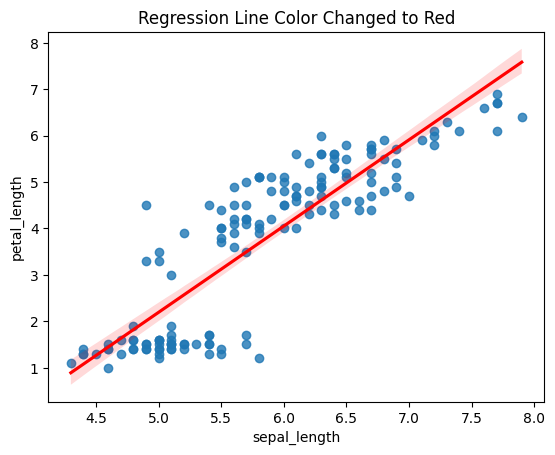

In [ ]:
#

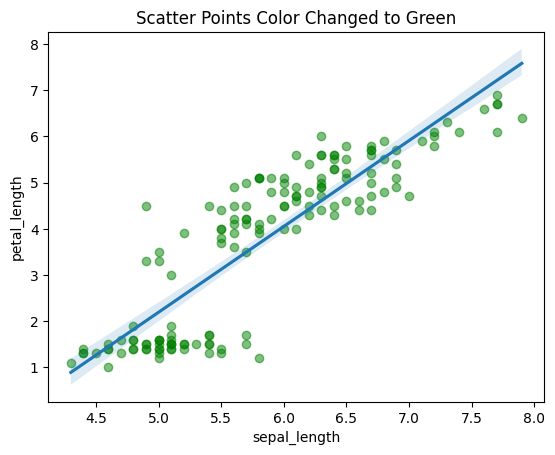

In [ ]:
#

### 4-2. `countplot()`과 `jointplot()`

- `countplot(x, hue, data)`: **범주형 데이터 빈도** 시각화
  - `x`: 시각화할 변수
  - `hue`: x, y 외에 구분할 변수
  - `data`: DataFrame
- `jointplot(x, y, data, kind)`: **산점도와 히스토그램을 함께** 출력
  - `x`, `y`: 축 데이터
  - `data`: DataFrame
  - `kind`: 그래프 종류 (`기본=scatter`)
    - `'scatter'`: 산점도(기본)
    - `'reg'`: 회귀선 추가
    - `'resid'`: 잔차 플롯 추가
    - `'kde'`: 커널 밀도 추정


In [19]:
# countplot 시연용 타이타닉 데이터 로드
titanic = sns.load_dataset('titanic')
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


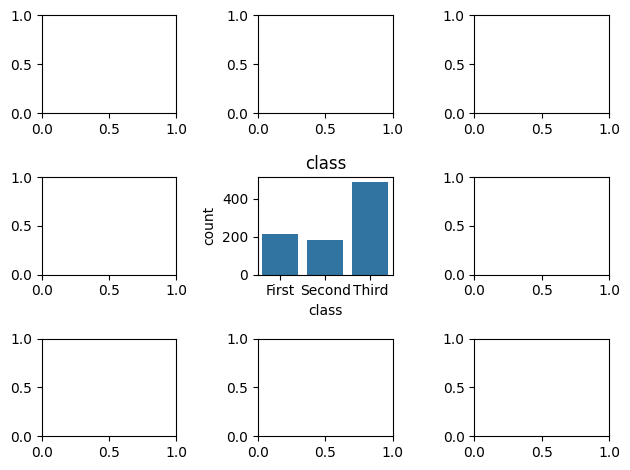

In [21]:
# countplot - 승객 등급별 빈도
# class 활용

# 3 x 3
fig, ax = plt.subplots(nrows = 3, ncols = 3)

# 정가운데 시각화를 그려주세요
sns.countplot(titanic, x = 'class', ax = ax[1, 1])
ax[1, 1].set_title("class")


plt.tight_layout()
plt.show()

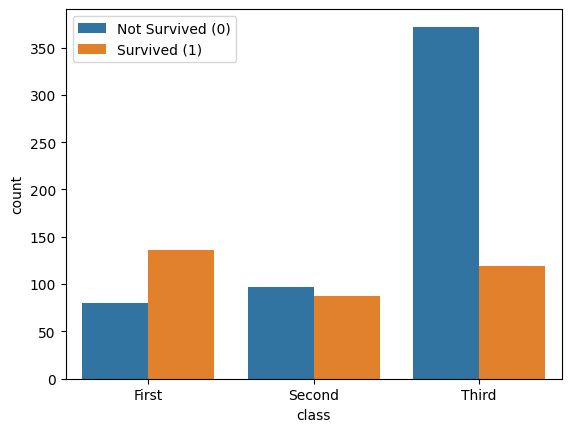

In [25]:
# hue로 생존 여부 구분
sns.countplot(titanic, x = 'class', hue = 'survived')
plt.legend(['Not Survived (0)', 'Survived (1)'])

In [26]:
# jointplot 용 tips 데이터셋
tips = sns.load_dataset('tips')
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


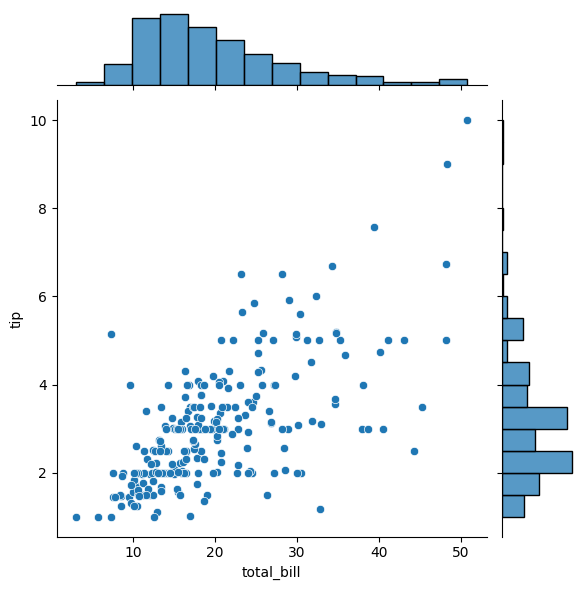

In [ ]:
# jointplot - 산점도 + 히스토그램 (기본 scatter)
sns.jointplot(data = tips, x = 'total_bill', y = 'tip')

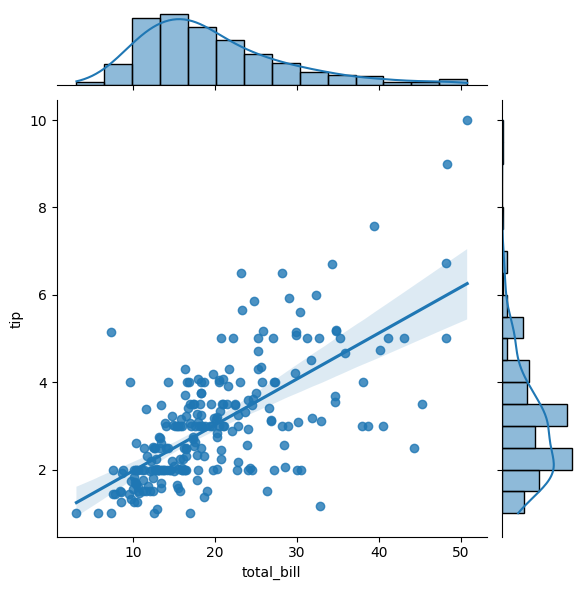

In [ ]:
# kind = 'reg' - 회귀선 추가
# jointplot - 산점도 + 히스토그램 (기본 scatter)
sns.jointplot(data = tips, x = 'total_bill', y = 'tip')

# 아래 산점도는 잔차의 등분산성을 위반

---
## Part 5. 타이타닉 생존 분석 & 로지스틱 회귀 모델

### 개요
- 타이타닉 데이터셋으로 다음을 수행합니다:
  1. Pandas, Matplotlib, Seaborn으로 **탐색적 데이터 분석(EDA)**
  2. NumPy와 Statsmodels로 **로지스틱 회귀 모델** 구축 (scikit-learn 미사용)
  3. 모델 성능 평가
  4. Streamlit 앱용 **모델 계수** 저장

### 로지스틱 회귀란?
- **이진 분류**(예: 생존=1, 사망=0)를 위한 통계 모델
- **시그모이드 함수**로 실수를 0~1 확률로 변환
- 식: P(y=1) = 1 / (1 + exp(-(b0 + b1*x1 + b2*x2 + ...)))
- 적합에는 `statsmodels.api.Logit` 사용


In [104]:
# 타이타닉 분석에 필요한 라이브러리 import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# scikit-learn 없이 로지스틱 회귀
import statsmodels.api as sm

# 출력 옵션 설정
%matplotlib inline
pd.set_option('display.max_columns', 20)

print("All libraries imported successfully.")


All libraries imported successfully.


### 5-1. 타이타닉 데이터셋 로드·탐색

- `sns.load_dataset('titanic')`으로 데이터 로드
- 주요 열:
  - `survived`: 생존 여부 (0=사망, 1=생존) — **목표 변수**
  - `pclass`: 승객 등급 (1, 2, 3등)
  - `sex`: 성별 (male/female)
  - `age`: 나이
  - `sibsp`: 동승 형제·배우자 수
  - `parch`: 동승 부모·자녀 수
  - `fare`: 요금
  - `embarked`: 승선 항구 (C=Cherbourg, Q=Queenstown, S=Southampton)


In [130]:
# 타이타닉 데이터셋 로드
titanic = sns.load_dataset('titanic')

# 상위 5행 출력
print("First 5 rows:")
print(titanic.head())
print()

# 데이터셋 shape
print("Shape:", titanic.shape)
print()

# 열 이름·자료형
print("Data types:")
print(titanic.dtypes)


First 5 rows:
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  

Shape: (891, 15)

Data types:
survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embark

In [131]:
#

In [132]:
# 전체 생존률
survival_rate = titanic['survived'].mean()

print(f"Overall survival rate : {survival_rate:.2%}")
print(f"Survived : {titanic['survived'].sum()} / Total : {len(titanic)}")

Overall survival rate : 38.38%
Survived : 342 / Total : 891


### 5-2. 탐색적 데이터 분석 (EDA)

- 데이터의 주요 패턴·관계를 시각화
- 살펴볼 질문:
  - 승객 등급이 생존에 어떤 영향을 주었는가?
  - 성별이 생존에 영향을 주었는가?
  - 생존자·비생존자의 나이 분포는?
  - 요금과 생존의 관계는?


/tmp/ipykernel_2985/2670223053.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Not Survived (0)', 'Survived (1)'])


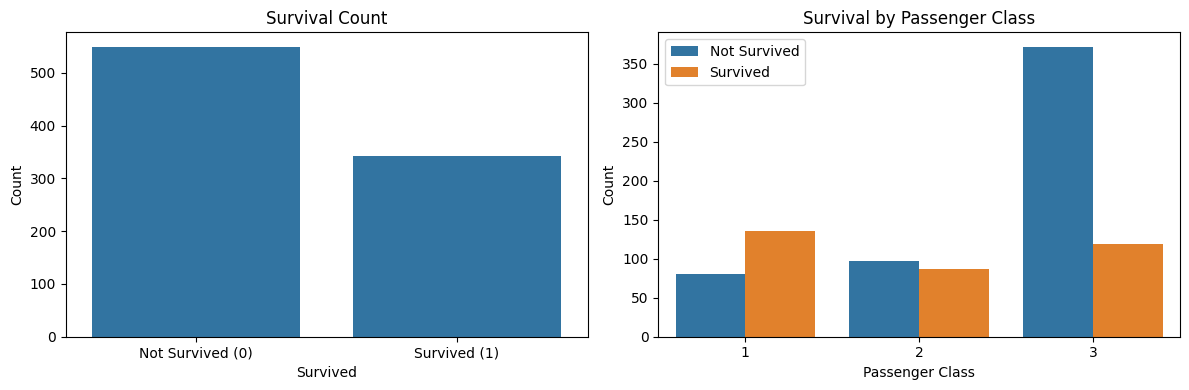

In [133]:
# 그림 1 : 전체 생존 건수
fig, axes = plt.subplots(1, 2, figsize = (12, 4))

# 왼쪽: 원시 건수
sns.countplot(x='survived', data=titanic, ax=axes[0])
axes[0].set_title('Survival Count')
axes[0].set_xticklabels(['Not Survived (0)', 'Survived (1)'])
axes[0].set_xlabel('Survived')
axes[0].set_ylabel('Count')

# 오른쪽: 승객 등급별
sns.countplot(x='pclass', hue='survived', data=titanic, ax=axes[1])
axes[1].set_title('Survival by Passenger Class')
axes[1].set_xlabel('Passenger Class')
axes[1].set_ylabel('Count')
axes[1].legend(['Not Survived', 'Survived'])

plt.tight_layout()
plt.show()

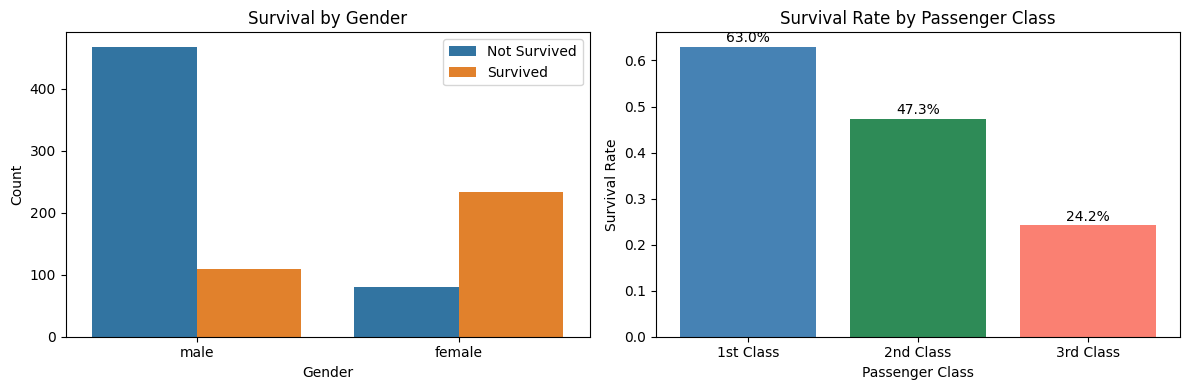

In [134]:
# 그림 2: 성별·등급별 생존
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 왼쪽: 성별 생존
sns.countplot(x='sex', hue='survived', data=titanic, ax=axes[0])
axes[0].set_title('Survival by Gender')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Count')
axes[0].legend(['Not Survived', 'Survived'])

# 오른쪽: 등급별 생존율
survival_by_class = titanic.groupby('pclass')['survived'].mean()
axes[1].bar(survival_by_class.index, survival_by_class.values,
            color=['steelblue', 'seagreen', 'salmon'])
axes[1].set_title('Survival Rate by Passenger Class')
axes[1].set_xlabel('Passenger Class')
axes[1].set_ylabel('Survival Rate')
axes[1].set_xticks([1, 2, 3])
axes[1].set_xticklabels(['1st Class', '2nd Class', '3rd Class'])
# 막대 위 값 라벨
for i, v in enumerate(survival_by_class.values):
    axes[1].text(i + 1, v + 0.01, f'{v:.1%}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()


In [135]:
#

In [136]:
#

### 5-3. 데이터 전처리

- 모델 학습 전에:
  1. **결측치 처리**: NaN 채우기 또는 삭제
  2. **범주형 인코딩**: 문자를 숫자로 변환
  3. **특성 선택**: 모델에 쓸 열 결정
  4. **정규화/스케일링**(선택, 수렴에 도움)

- 사용할 특성:
  - `pclass` (1, 2, 3) — 승객 등급
  - `sex` (0=남, 1=여) — 인코딩된 성별
  - `age` — 나이 (결측은 중앙값으로 대체)
  - `sibsp` — 형제·배우자 수
  - `parch` — 부모·자녀 수
  - `fare` — 요금 (결측은 중앙값으로 대체)


In [137]:
# 1단계 : 모델에 쓸 열 선택
cols = ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare']
df_model = titanic[cols].copy()

print("selected columns : ")
print(df_model.head())
print()
print("Missing values before cleaning")

selected columns : 
   survived  pclass     sex   age  sibsp  parch     fare
0         0       3    male  22.0      1      0   7.2500
1         1       1  female  38.0      1      0  71.2833
2         1       3  female  26.0      0      0   7.9250
3         1       1  female  35.0      1      0  53.1000
4         0       3    male  35.0      0      0   8.0500

Missing values before cleaning


In [138]:
# 2단계 : 결측치 처리
# age 결측 - 중앙값으로 대체
age_median = df_model['age'].median()
df_model['age'] = df_model['age'].fillna(age_median)

# fare 결측 - 중앙값으로 대체
fare_median = df_model['fare'].median()
df_model['fare'] = df_model['fare'].fillna(fare_median)

print("Missing values after filling : ")
print(df_model.isnull().sum())

Missing values after filling : 
survived    0
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
dtype: int64


In [139]:
df_model.head(10)

,survived,pclass,sex,age,sibsp,parch,fare
0,0,3,male,22.0,1,0,7.2500
1,1,1,female,38.0,1,0,71.2833
2,1,3,female,26.0,0,0,7.9250
3,1,1,female,35.0,1,0,53.1000
4,0,3,male,35.0,0,0,8.0500
5,0,3,male,28.0,0,0,8.4583
6,0,1,male,54.0,0,0,51.8625
7,0,3,male,2.0,3,1,21.0750
8,1,3,female,27.0,0,2,11.1333
9,1,2,female,14.0,1,0,30.0708


In [140]:
# 3단계 : 범주형 'sex' 인코딩
# male -> 0, female -> 1 (성별 이진 인코딩)

df_model['sex'] = df_model['sex'].map({'male' : 0 , 'female' : 1})

print("After encoding 'sex' (male = 0, female = 1) : ")
print(df_model.head())

After encoding 'sex' (male = 0, female = 1) : 
   survived  pclass  sex   age  sibsp  parch     fare
0         0       3    0  22.0      1      0   7.2500
1         1       1    1  38.0      1      0  71.2833
2         1       3    1  26.0      0      0   7.9250
3         1       1    1  35.0      1      0  53.1000
4         0       3    0  35.0      0      0   8.0500


In [141]:
# 4단계: 최종 데이터셋 확인
print("Final dataset shape:", df_model.shape)
print()
print("Data types:")
print(df_model.dtypes)
print()
print("Statistical summary:")
print(df_model.describe())


Final dataset shape: (891, 7)

Data types:
survived      int64
pclass        int64
sex           int64
age         float64
sibsp         int64
parch         int64
fare        float64
dtype: object

Statistical summary:
         survived      pclass         sex         age       sibsp       parch  \
count  891.000000  891.000000  891.000000  891.000000  891.000000  891.000000   
mean     0.383838    2.308642    0.352413   29.361582    0.523008    0.381594   
std      0.486592    0.836071    0.477990   13.019697    1.102743    0.806057   
min      0.000000    1.000000    0.000000    0.420000    0.000000    0.000000   
25%      0.000000    2.000000    0.000000   22.000000    0.000000    0.000000   
50%      0.000000    3.000000    0.000000   28.000000    0.000000    0.000000   
75%      1.000000    3.000000    1.000000   35.000000    1.000000    0.000000   
max      1.000000    3.000000    1.000000   80.000000    8.000000    6.000000   

             fare  
count  891.000000  
mean    32.

### 5-4. 학습/검증 분할 (NumPy 수동)

- scikit-learn 없이 NumPy로 데이터 분할
- **80/20 분할**: 학습 80%, 검증 20%
- 순서 편향을 피하려면 **무작위 셔플**이 중요


In [142]:
# NumPy로 학습/검증 분할 (sklearn 미사용)


# 재현성을 위한 난수 시드
np.random.seed(42)

# 셔플된 인덱스 배열 생성
n = len(df_model)
indices = np.arange(n)
np.random.shuffle(indices)

# 학습 80%, 검증 20%
train_size = int(0.8 * n)
train_idx = indices[:train_size]
test_idx = indices[train_size:]


# DataFrame 분할
train_df = df_model.iloc[train_idx].reset_index(drop = True)
test_df = df_model.iloc[test_idx].reset_index(drop = True)

print(f"Total samples: {n}")
print(f"Training samples: {len(train_df)} ({len(train_df)/n:.0%})")
print(f"Testing samples: {len(test_df)} ({len(test_df)/n:.0%})")
print()

# 특성(X)과 목표(y) 분리
feature_cols = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare']

X_train = train_df[feature_cols].values
y_train = train_df['survived'].values

X_test = test_df[feature_cols].values
y_test = test_df['survived'].values

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

Total samples: 891
Training samples: 712 (80%)
Testing samples: 179 (20%)

X_train shape: (712, 6)
y_train shape: (712,)
X_test shape: (179, 6)
y_test shape: (179,)


In [143]:
test_df.head()

,survived,pclass,sex,age,sibsp,parch,fare
0,0,2,0,26.0,0,0,10.5000
1,0,3,0,41.0,0,0,7.1250
2,1,1,0,48.0,1,0,76.7292
3,1,2,1,48.0,1,2,65.0000
4,1,1,1,48.0,1,0,39.6000


In [144]:
train_df.head()

,survived,pclass,sex,age,sibsp,parch,fare
0,1,3,0,28.0,1,1,15.2458
1,0,2,0,31.0,0,0,10.5000
2,0,3,0,20.0,0,0,7.9250
3,1,2,1,6.0,0,1,33.0000
4,1,3,1,14.0,1,0,11.2417


### 5-5. Statsmodels 로지스틱 회귀

- `statsmodels.api.Logit`으로 로지스틱 회귀
- 단계:
  1. `sm.add_constant()`로 X에 **상수항(절편)** 추가
  2. `model.fit()`으로 **적합**
  3. **요약 통계** 확인
  4. `model.predict()`로 **확률** 예측
  5. 임계값(0.5)으로 **이진 예측** 변환


In [145]:
# 1단계: 특성 행렬에 상수항(절편) 추가
# statsmodels는 절편을 명시적으로 추가해야 함
X_train_sm = sm.add_constant(X_train)
X_test_sm = sm.add_constant(X_test)

print("X_train_sm shape (with constant):", X_train_sm.shape)
print("First row of X_train_sm:", X_train_sm[0])

X_train_sm shape (with constant): (712, 7)
First row of X_train_sm: [ 1.      3.      0.     28.      1.      1.     15.2458]


In [146]:
# 2단계: 로지스틱 회귀 모델 생성·적합
# sm.Logit(종속변수=target, 설명변수=features)
logit_model = sm.Logit(y_train, X_train_sm)

# fit() — 최대우도추정(MLE)으로 계수 추정
result = logit_model.fit()

Optimization terminated successfully.
         Current function value: 0.445189
         Iterations 6


In [147]:
# 3단계 : 모델 요약 출력
print(result.summary())

                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                  712
Model:                          Logit   Df Residuals:                      705
Method:                           MLE   Df Model:                            6
Date:                Mon, 29 Jun 2026   Pseudo R-squ.:                  0.3339
Time:                        07:15:30   Log-Likelihood:                -316.97
converged:                       True   LL-Null:                       -475.84
Covariance Type:            nonrobust   LLR p-value:                 1.290e-65
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.4104      0.539      4.472      0.000       1.354       3.467
x1            -1.0959      0.156     -7.014      0.000      -1.402      -0.790
x2             2.6684      0.221     12.084      0.0

In [148]:
# 4단계 : 계수 해석
feature_names = ['const (intercept)'] + feature_cols
coef_df = pd.DataFrame ({
    'Feature' : feature_names,
    'p-value' : result.pvalues,
    'Odds Ratio' : np.exp(result.params) # exp(계수) = 오즈비 로직 변환시켜주면 자동으로 log를 씌우기 때문에 해줘야함
})

print("Model Coefficients and Odds Ratios:")
print(coef_df.round(4))
print()
print("Interpretation:")
print("- Coefficient > 0: positive effect on survival probability")
print("- Coefficient < 0: negative effect on survival probability")
print("- Odds Ratio > 1: increases survival odds")
print("- Odds Ratio < 1: decreases survival odds")

Model Coefficients and Odds Ratios:
             Feature  p-value  Odds Ratio
0  const (intercept)   0.0000     11.1385
1             pclass   0.0000      0.3342
2                sex   0.0000     14.4166
3                age   0.0000      0.9563
4              sibsp   0.0012      0.6712
5              parch   0.6293      0.9426
6               fare   0.2038      1.0033

Interpretation:
- Coefficient > 0: positive effect on survival probability
- Coefficient < 0: negative effect on survival probability
- Odds Ratio > 1: increases survival odds
- Odds Ratio < 1: decreases survival odds


In [149]:
# 5단계: 검증 세트 예측
# predict() — 확률(0~1) 반환
y_pred_prob = result.predict(X_test_sm)

# 임계값 0.5로 이진 예측 변환
y_pred = (y_pred_prob >= 0.5).astype(int)

print("First 10 predictions:")
print(f"Probabilities: {y_pred_prob[:10].round(3)}")
print(f"Predicted:     {y_pred[:10]}")
print(f"Actual:        {y_test[:10]}")

First 10 predictions:
Probabilities: [0.287 0.064 0.274 0.608 0.828 0.065 0.884 0.305 0.261 0.276]
Predicted:     [0 0 0 1 1 0 1 0 0 0]
Actual:        [0 0 1 1 1 0 1 1 0 0]


### 5-6. 모델 평가

- 다음 지표로 평가:
  - **정확도(Accuracy)**: 올바르게 분류한 비율
  - **혼동 행렬**: TP, FP, TN, FN
  - **정밀도·재현율**: 클래스별 성능 이해
  - 모두 NumPy로 직접 계산 (scikit-learn 미사용)


In [150]:
# NumPy로 정확도 직접 계산
accuracy = np.mean(y_pred == y_test)
print(f"Model Accuracy on Test Set: {accuracy:.2%}")
print()


# 혼동 행렬 (수동 계산)
# TP: 예측 1, 실제 1
# TN: 예측 0, 실제 0
# FP: 예측 1, 실제 0
# FN: 예측 0, 실제 1
TP = np.sum((y_pred == 1) & (y_test == 1))
TN = np.sum((y_pred == 0) & (y_test == 0))
FP = np.sum((y_pred == 1) & (y_test == 0))
FN = np.sum((y_pred == 0) & (y_test == 1))

print("Confusion Matrix:")
print(f"              Predicted 0    Predicted 1")
print(f"Actual 0         TN={TN:3d}       FP={FP:3d}")
print(f"Actual 1         FN={FN:3d}       TP={TP:3d}")
print()

# 정밀도, 재현율, F1 점수
precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print(f"Precision: {precision:.2%}  (of predicted survivors, how many actually survived)")
print(f"Recall:    {recall:.2%}  (of actual survivors, how many did we find)")
print(f"F1-Score:  {f1:.2%}  (harmonic mean of precision and recall)")


Model Accuracy on Test Set: 77.65%

Confusion Matrix:
              Predicted 0    Predicted 1
Actual 0         TN= 93       FP= 21
Actual 1         FN= 19       TP= 46

Precision: 68.66%  (of predicted survivors, how many actually survived)
Recall:    70.77%  (of actual survivors, how many did we find)
F1-Score:  69.70%  (harmonic mean of precision and recall)


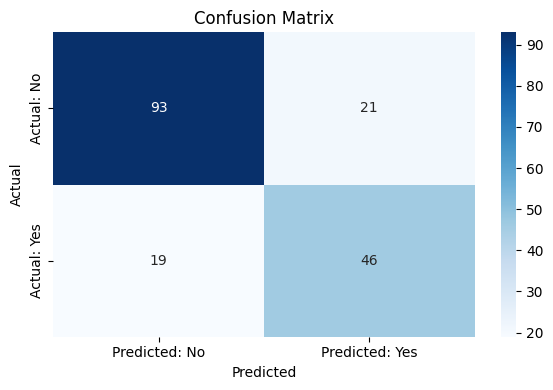

In [151]:
# 혼동 행렬 히트맵 시각화
conf_matrix = np.array([[TN, FP], [FN, TP]])

plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted: No', 'Predicted: Yes'],
            yticklabels=['Actual: No', 'Actual: Yes'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()


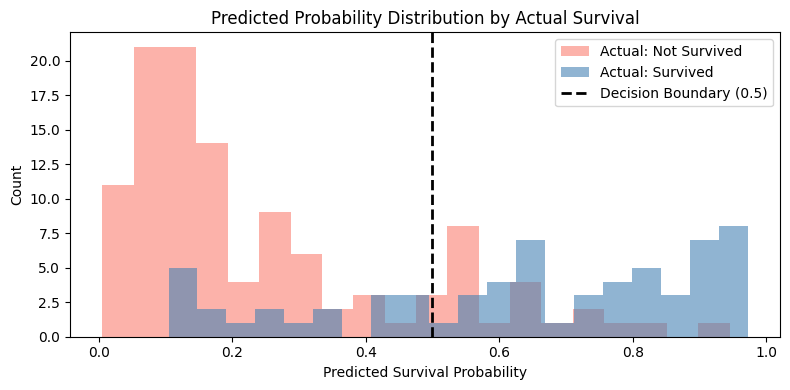

In [152]:
# 생존 그룹별 예측 확률 분포
plt.figure(figsize=(8, 4))

# 실제 생존 여부별 확률 분리
survived_probs = y_pred_prob[y_test == 1]
not_survived_probs = y_pred_prob[y_test == 0]

plt.hist(not_survived_probs, bins=20, alpha=0.6,
         label='Actual: Not Survived', color='salmon')
plt.hist(survived_probs, bins=20, alpha=0.6,
         label='Actual: Survived', color='steelblue')

# 결정 경계 0.5 표시
plt.axvline(x=0.5, color='black', linestyle='--', linewidth=2, label='Decision Boundary (0.5)')

plt.xlabel('Predicted Survival Probability')
plt.ylabel('Count')
plt.title('Predicted Probability Distribution by Actual Survival')
plt.legend()
plt.tight_layout()
plt.show()

### 5-7. 특성 중요도 시각화

- 각 **계수 크기**를 시각화해 어떤 특성이 중요한지 파악
- 절댓값이 클수록 생존 예측에 **영향이 큼**
- 모델 해석·결과 전달에 도움


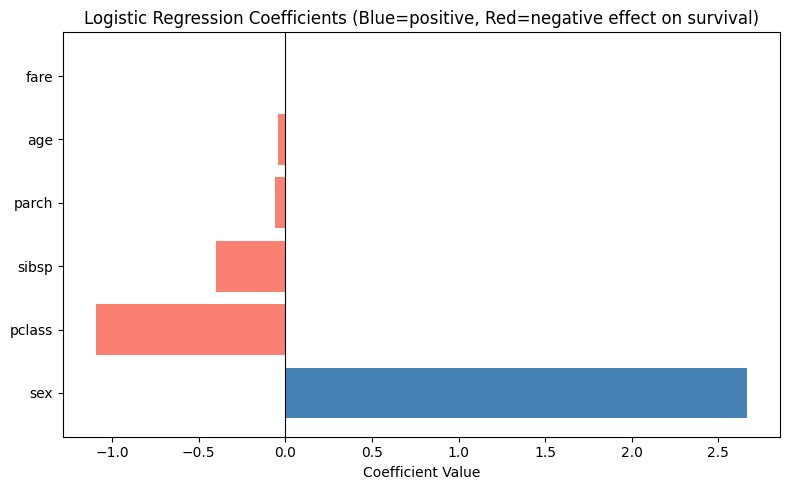

Feature importance summary:
  sex       : coef=+2.668  -> increases survival probability
  pclass    : coef=-1.096  -> decreases survival probability
  sibsp     : coef=-0.399  -> decreases survival probability
  parch     : coef=-0.059  -> decreases survival probability
  age       : coef=-0.045  -> decreases survival probability
  fare      : coef=+0.003  -> increases survival probability


In [153]:
# 계수 크기 기반 특성 중요도
# 시각화에서 절편(const) 제외
coef_vals = result.params[1:]   # 절편 제외
feature_labels = feature_cols

# 절댓값 기준 정렬
sorted_idx = np.argsort(np.abs(coef_vals))[::-1]

plt.figure(figsize=(8, 5))
colors = ['steelblue' if c > 0 else 'salmon' for c in coef_vals[sorted_idx]]
plt.barh(
    [feature_labels[i] for i in sorted_idx],
    coef_vals[sorted_idx],
    color=colors
)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.xlabel('Coefficient Value')
plt.title('Logistic Regression Coefficients (Blue=positive, Red=negative effect on survival)')
plt.tight_layout()
plt.show()

print("Feature importance summary:")
for i in sorted_idx:
    direction = "increases" if coef_vals[i] > 0 else "decreases"
    print(f"  {feature_labels[i]:10s}: coef={coef_vals[i]:+.3f}  -> {direction} survival probability")


### 5-8. 모델 계수 저장

- 모델 계수와 메타데이터를 **CSV**로 저장
- Streamlit 앱이 **재학습 없이** 모델을 로드해 사용
- 로지스틱 회귀는 계수만으로 모델이 완전히 정의됨


In [154]:
#

In [155]:
#